In [1]:
# Загружаем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Загружаем таблицы
df_products = pd.read_csv('products.csv')
df_orders = pd.read_csv('orders.csv')
df_order_items = pd.read_csv('order_items.csv')
df_users = pd.read_csv('users.csv')
df_categories = pd.read_csv('categories.csv')
df_transactions = pd.read_csv('transactions.csv')
df_reviews = pd.read_csv('reviews.csv')

In [3]:
# Проверка на наличие дубликатов по всем столбцам
duplicates_count_products = df_products.duplicated().sum()
duplicates_count_orders = df_orders.duplicated().sum()
duplicates_count_order_items = df_order_items.duplicated().sum()
duplicates_count_users = df_users.duplicated().sum()
duplicates_count_categories = df_categories.duplicated().sum()
duplicates_count_transactions = df_transactions.duplicated().sum()
duplicates_count_reviews = df_reviews.duplicated().sum()

# Словарь с результатами для удобной обработки
duplicates_info = {
    "products": duplicates_count_products,
    "orders": duplicates_count_orders,
    "order_items": duplicates_count_order_items,
    "users": duplicates_count_users,
    "categories": duplicates_count_categories,
    "transactions": duplicates_count_transactions,
    "reviews": duplicates_count_reviews,
}

for table_name, count in duplicates_info.items():
    if count > 0:
        print(f"Количество дубликатов в таблице {table_name}: {count}")
    else:
        print(f"В таблице {table_name} дубликатов не обнаружено")

В таблице products дубликатов не обнаружено
В таблице orders дубликатов не обнаружено
В таблице order_items дубликатов не обнаружено
В таблице users дубликатов не обнаружено
В таблице categories дубликатов не обнаружено
В таблице transactions дубликатов не обнаружено
В таблице reviews дубликатов не обнаружено


In [4]:
# Проверка на наличие пропущенных значений (NULL) по всем столбцам
tables = {
    "products": df_products,
    "orders": df_orders,
    "order_items": df_order_items,
    "users": df_users,
    "categories": df_categories,
    "transactions": df_transactions,
    "reviews": df_reviews,
}

for table_name, df in tables.items():
    missing_values = df.isnull().sum()
    total_missing = missing_values.sum()
    
    print(f"\n--- Таблица {table_name} ---")
    if total_missing == 0:
        print("Пропущенных значений не обнаружено")
    else:
        # Выводим только те столбцы, где есть пропуски
        print(missing_values[missing_values > 0])


--- Таблица products ---
Пропущенных значений не обнаружено

--- Таблица orders ---
Пропущенных значений не обнаружено

--- Таблица order_items ---
Пропущенных значений не обнаружено

--- Таблица users ---
Пропущенных значений не обнаружено

--- Таблица categories ---
parent_category_id    885
dtype: int64

--- Таблица transactions ---
Пропущенных значений не обнаружено

--- Таблица reviews ---
Пропущенных значений не обнаружено


In [5]:
# Преобразование столбцов с датами в тип datetime
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'], errors='coerce')
df_reviews['review_date'] = pd.to_datetime(df_reviews['review_date'], errors='coerce')
df_transactions['transaction_date'] = pd.to_datetime(df_transactions['transaction_date'], errors='coerce')
df_users['registration_date'] = pd.to_datetime(df_users['registration_date'], errors='coerce')

# Проверка результата
for name, df, col in [
    ('orders', df_orders, 'order_date'),
    ('reviews', df_reviews, 'review_date'),
    ('transactions', df_transactions, 'transaction_date'),
    ('users', df_users, 'registration_date'),
]:
    print(f"{name}.{col}: {df[col].dtype}")

orders.order_date: datetime64[ns]
reviews.review_date: datetime64[ns]
transactions.transaction_date: datetime64[ns]
users.registration_date: datetime64[ns]


In [6]:
# Находим строки с отрицательными значениями цен в таблице products
df_products.loc[df_products["price"] < 0, "price"] = 0

negative_count = (df_products["price"] < 0).sum()
if negative_count == 0:
    print("Проверка пройдена: отрицательных цен нет.")
else:
    print(f"Ошибка: осталось {negative_count} строк с отрицательной ценой.")

Проверка пройдена: отрицательных цен нет.


In [7]:
# Добавляем новый столбец rating_category в таблицу reviews
def categorize_rating(rating):
    if rating >= 4.5:
        return 'High'
    elif rating >= 4:
        return 'Medium'
    else:
        return 'Low'

df_reviews['rating_category'] = df_reviews['rating'].apply(categorize_rating)

assert 'rating_category' in df_reviews.columns, "Столбец rating_category не был добавлен в датафрейм"
print("Проверка пройдена: столбец rating_category присутствует в датафрейме")

Проверка пройдена: столбец rating_category присутствует в датафрейме


Статистики по признакам 'price' и 'stock_quantity':
              price  stock_quantity
count  52100.000000    52100.000000
mean     506.569939      500.620461
std      285.605499      287.761399
min       10.020000        0.000000
25%      260.072500      254.000000
50%      507.810000      502.000000
75%      754.180000      747.000000
max      999.990000     1000.000000


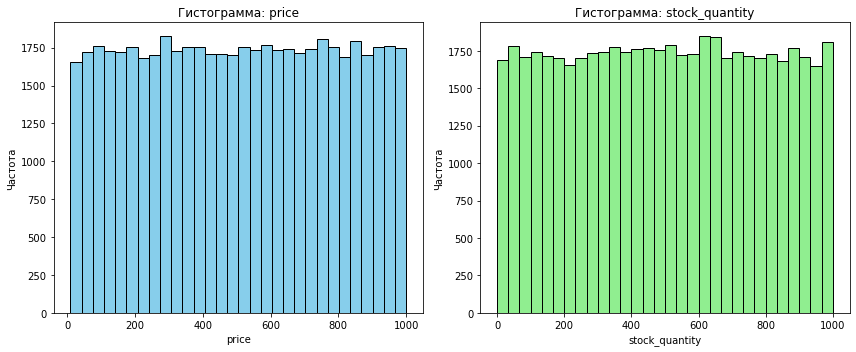

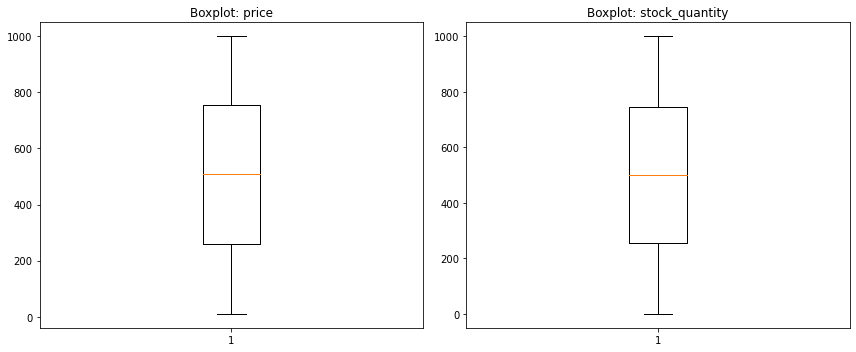


Корреляционная матрица:
                   price  stock_quantity
price           1.000000        0.000815
stock_quantity  0.000815        1.000000


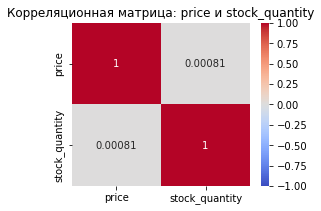

In [8]:
# 1. Статистики методом describe()
stats = df_products[['price', 'stock_quantity']].describe()
print("Статистики по признакам 'price' и 'stock_quantity':")
print(stats)

# 2. Гистограммы
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_products['price'].dropna(), bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Гистограмма: price')
axes[0].set_xlabel('price')
axes[0].set_ylabel('Частота')

axes[1].hist(df_products['stock_quantity'].dropna(), bins=30, color='lightgreen', edgecolor='black')
axes[1].set_title('Гистограмма: stock_quantity')
axes[1].set_xlabel('stock_quantity')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

# 3. Boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(df_products['price'].dropna())
axes[0].set_title('Boxplot: price')

axes[1].boxplot(df_products['stock_quantity'].dropna())
axes[1].set_title('Boxplot: stock_quantity')

plt.tight_layout()
plt.show()

# 4. Корреляционная матрица
corr_matrix = df_products[['price', 'stock_quantity']].corr()
print("\nКорреляционная матрица:")
print(corr_matrix)

# Визуализация корреляционной матрицы (опционально)
plt.figure(figsize=(4, 3))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляционная матрица: price и stock_quantity')
plt.show()

In [9]:
import os

output_dir = 'exported_csv'
os.makedirs(output_dir, exist_ok=True)

# Фильтрация по дате: только заказы с 01.01.2025 по 01.06.2025
orders_filtered = df_orders[
    (df_orders['order_date'] >= '2025-01-01') &
    (df_orders['order_date'] <= '2025-06-01')
]

orders_path = os.path.join(output_dir, 'orders_filtered.csv')
orders_filtered.to_csv(orders_path, sep=";", index=False)

print(f"Таблица заказов успешно выгружена: {orders_path}")
print(f"Строк: {orders_filtered.shape[0]}, Колонок: {orders_filtered.shape[1]}")

Таблица заказов успешно выгружена: exported_csv\orders_filtered.csv
Строк: 246456, Колонок: 5
